# Clustering financial time series

In [2]:
!pip install arch

                                              0.0/853.2 kB ? eta -:--:--
     ---------------                        337.9/853.2 kB 7.0 MB/s eta 0:00:01
     --------------------------------       737.3/853.2 kB 7.7 MB/s eta 0:00:01
     -------------------------------------- 853.2/853.2 kB 7.7 MB/s eta 0:00:00


In [29]:
import os
import pandas as pd
import numpy as np
import random
import itertools
from arch import arch_model
from scipy.stats import shapiro
from scipy.stats import probplot
from statsmodels.stats.diagnostic import het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

from matplotlib import pyplot as plt
plt.style.use('fivethirtyeight') 
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
%matplotlib inline

,MET,MLM,GS,ALK,HSY,BA,XRAY,VMC
date,,,,,,,,
2013-02-08,36.90,98.27,151.60,24.335,80.21,76.56,42.87,56.08
2013-02-11,36.90,98.07,152.24,24.400,80.38,75.87,42.84,55.65
2013-02-12,37.13,98.43,154.11,24.430,80.77,75.99,42.87,56.12
2013-02-13,37.50,99.53,154.52,24.760,81.35,74.78,43.08,55.86
2013-02-14,36.69,100.35,155.93,24.355,80.89,74.93,42.91,54.87


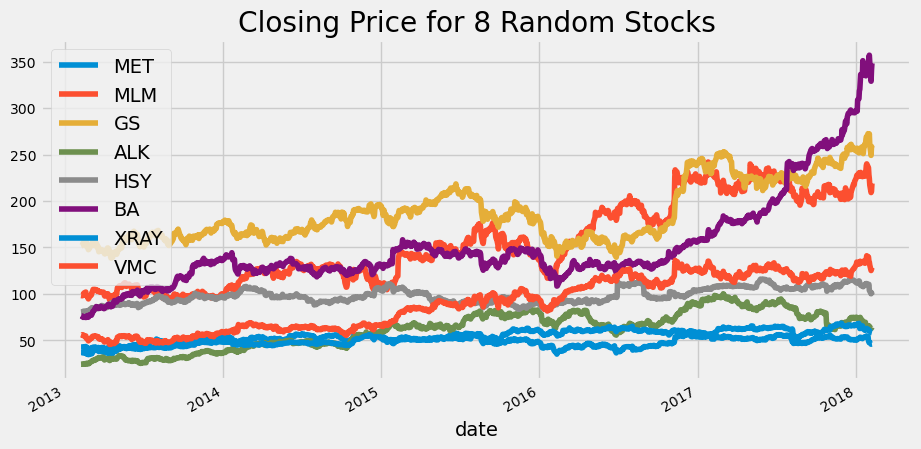

In [30]:
path = r'C:\Users\79308\Desktop\patel\Cluster\9 Clustering financial time series\archive (9)\individual_stocks_5yr\individual_stocks_5yr'
csvs = [os.path.join(path, file) for file in os.listdir(path) if file.endswith('.csv')]

df = pd.DataFrame()
for file in random.sample(range(1, len(csvs)), 8):
    stock_df = pd.read_csv(csvs[file])
    stock_df.index = pd.DatetimeIndex(stock_df.date)
    name = stock_df['Name'].iloc[0]
    df[name] = stock_df['close']

df.plot(figsize=(10, 5), title='Closing Price for 8 Random Stocks')
df.head()

<a id='hetero'></a>
## Heteroskedasticity
We can think about an idealized time series as a set of observations chosen independently and from identical distributions. Understanding this series is as easy as estimating the parameters of the distribution. This is the idea behind stationarity. Once a time series is stationary, we can learn the parameters of the distirbution and forecast, but rarely is it that easy. This kernel is about time series that exhibit heteroskedasticity, specifically conditional heteroskedasticity and the models we use to forecast them.

If we return to  the idealized time series, heteroskedasticity is when the variance of the underlying distribution used to construct our time series changes as a function of time. A common appearance of heterskedasticity is a time series whose variance increases with time, growing outward in a conal pattern. Small amounts of heteroskedasticity can sometimes be masked by a Box-Cox transformation, which makes the data distribution more normal. In our forecasts of the S&P500, not only are our changes in variance too great to mask but the variance at step $x_t$ is conditional on the variance of past time steps, $x_{t-1}$. This is called conditional heteroskedasticity or *volatility clustering*.  

<a id='volatile'></a>
## Volatility Clustering
Volatility clustering is the behavior behind the familiar jagged peaks of financial time series. When we look at the plot above we can see there are periods of high and low volatility. Periods where a positive feedback loop forms and changes in variance give rise to greater changes in variance punctuated by periods of relative calm. The ARCH and GARCH models, which we'll introduce shortly, are designed to model the variance for volatile time series. Note, these models do not forecast estimated values. The ARCH and GARCH models specifically capture the expected variance of the residuals from another model. To forecast financial markets we would use ARCH  and GARCH after applying another model like ARIMA first.

<a id='arch'></a>
## Autoregressive Conditional Heteroskedasticity (ARCH)
If you're familiar with autoregressive (AR) models, ARCH is easy to understand. In an AR model the current value is dependent on $p$ previous timesteps where $p$ lagged values were highly correlated with the current timestep. With ARCH, the variance of the current time step is dependent on $p$ lagged squared standard error terms, with coefficients $\alpha$. The standard error is the difference between the observed and predicted value from another model. 

$$\sigma^2_t=\alpha_0+\alpha_1u^2_{t-1}+\alpha_2u^2_{t-2}+...+\alpha_pu^2_{t-p}$$

If the volatility tends to cluster then recent large squared errors are likely to lead to large variance, and more large squared errors. Like fitting an AR model we can look at PACF and ACF plots to see where our series is autocorrelated and use that to choose a value for our parameter, $p$. If we have an ARCH(1) or a first order ARCH model we assume the series is stationary except for the change in variance. We often use ARCH models in conjunction with another AR or ARMA model where we would pass the ARCH model the squared residuals from the ARMA model. We can also pass ARCH a mean process, as in the case of this kernel where we will pass the percent changes in stock closing value- which is a series that will hover around 0. 

<a id='garch'></a>
## Generalized Autoregressive Conditional Heteroskedasticity (GARCH)
GARCH extends ARCH by allowing the variance to depend on its own lags and the lags of the squared residuals. GARCH can capture greater changes like increasing and decreasing volatility. 

$$\sigma^2_t=\alpha_0+\alpha_1u^2_{t-1}+\alpha_2u^2_{t-2}+...+\alpha_pu^2_{t-p}+\beta_1\sigma^2_{t-1}+...+\beta_p\sigma^2_{t-q}$$

We have two parameters for GARCH(q, p):
* $q$: Number of lag variances
* $p$: Number of lag residual errors 

The parameters we're using here are consistent with the ARCH python library but more often the swapped notation is used. 

GARCH often fits data better than ARCH when there's heteroskedasticity and volatility clustering. We will perform an analysis with both GARCH and ARCH and explain the results but there are lots of variations on the GARCH model that introduce new parameters for the specific behaviors of volatility. 

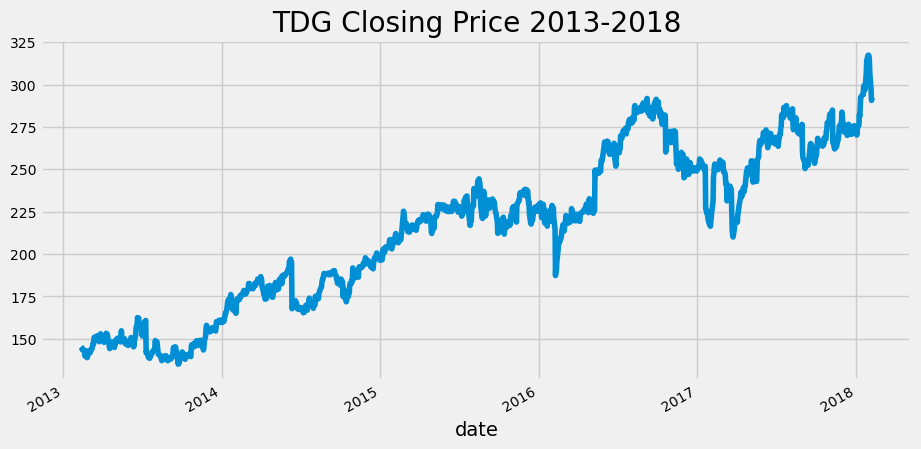

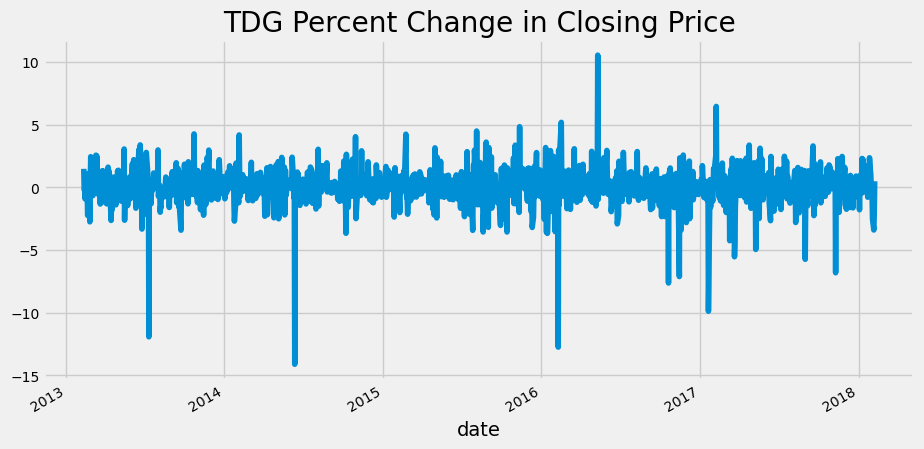

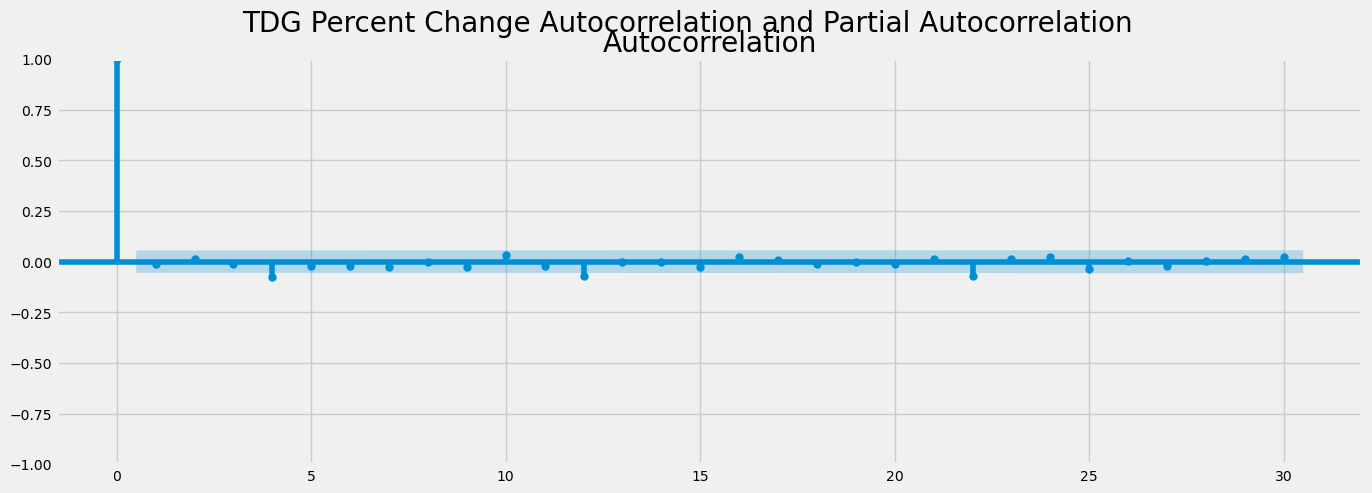

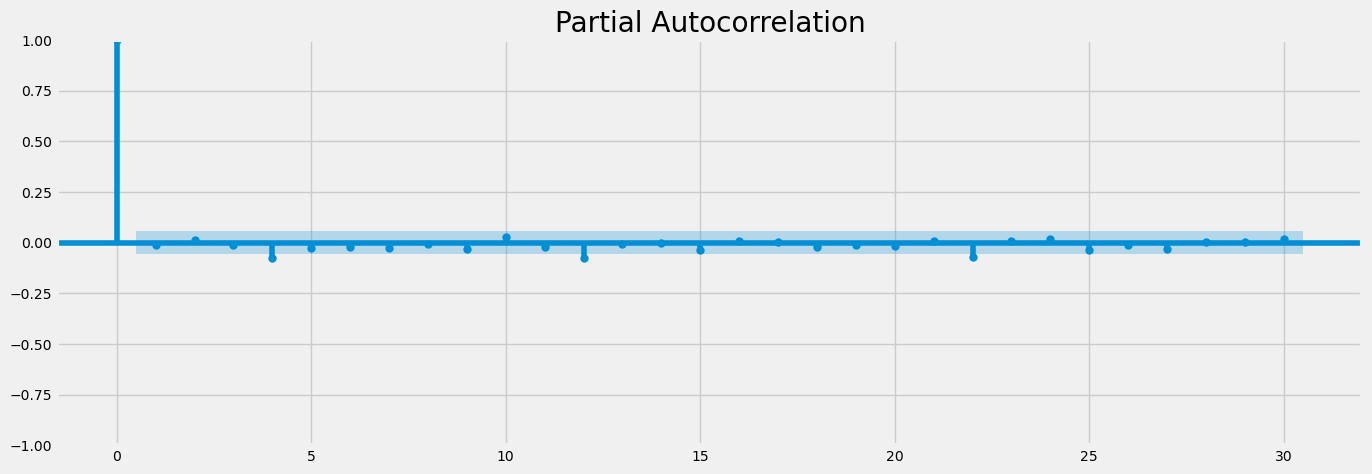

In [31]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

stock = 'TDG'
file_path = r'C:\Users\79308\Desktop\patel\Cluster\9 Clustering financial time series\archive (9)\individual_stocks_5yr\individual_stocks_5yr'
file_name = f'{stock}_data.csv'
file_full_path = os.path.join(file_path, file_name)

df = pd.read_csv(file_full_path)
df.index = pd.DatetimeIndex(df.date)
df = df.drop(columns=['open', 'high', 'low', 'volume', 'date', 'Name'])
df['pct_change'] = 100 * df['close'].pct_change()
df.dropna(inplace=True)

df['close'].plot(figsize=(10, 5), title=f'{stock} Closing Price 2013-2018')
plt.show()

df['pct_change'].plot(figsize=(10, 5), title=f'{stock} Percent Change in Closing Price')
plt.show()

acf = plot_acf(df['pct_change'], lags=30)
pacf = plot_pacf(df['pct_change'], lags=30)
acf.suptitle(f'{stock} Percent Change Autocorrelation and Partial Autocorrelation', fontsize=20)
acf.set_figheight(5)
acf.set_figwidth(15)
pacf.set_figheight(5)
pacf.set_figwidth(15)
plt.show()


---
## Step 1 & 2: Clustering Pipeline (PyCaret)

Automated clustering pipeline with PyCaret:
- `setup()` → preprocessing & configuration
- `create_model()` → K-Means clustering
- `assign_model()` → assign cluster labels
- `plot_model()` → visualize clusters


In [ ]:
from pycaret.clustering import *

clust_setup = setup(data=df, normalize=True, session_id=42, verbose=False)

# Create K-Means model
kmeans_model = create_model('kmeans')
print(kmeans_model)


In [ ]:
# Assign cluster labels to data
clustered_df = assign_model(kmeans_model)
clustered_df.head()


In [ ]:
# Evaluate clustering
plot_model(kmeans_model, plot='elbow')


In [ ]:
# Silhouette plot
plot_model(kmeans_model, plot='silhouette')


In [ ]:
# Distribution plot
plot_model(kmeans_model, plot='distribution')